<a target="_blank" href="https://colab.research.google.com/github/paulotguerra/QXD0178/blob/main/03.E0-Exercicio-Agrupamento-de-Dados.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## QXD0178 - Mineração de Dados
# Agrupamento de dados

**Professor:** Marcos Antonio de Oliveira ([marcos.oliveira@ufc.br](mailto:marcos.oliveira@ufc.br))


# Lista de Exercícios: Agrupamento de dados

Nesta lista de exercícios, você explorará a aplicação de métodos de aprendizado de máquina para realizar tarefas de agrupamento de dados (*clustering*). Você usará a base de dados [Iris plants dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-plants-dataset) e avaliará algoritmos de agrupamento para comparar sua efetividade. O objetivo é entender como diferentes métodos de aprendizado de máquina se comportam em relação à tarefa de agrupamento de dados.

Você deverá utilizar os algoritmos [K-Means](https://scikit-learn.org/stable/modules/clustering.html#k-means), [Gaussian Mixture](https://scikit-learn.org/stable/modules/mixture.html#mixture) e [DBSCAN](https://scikit-learn.org/stable/modules/clustering.html#dbscan) e comparar o resultado produzido por cada modelo para o seguinte conjunto de hiperparâmtros, quando aplicável aquele modelo.

* K-means:
    * Centróides (`n_clusters`): 2, 3, e 6.    
* Gaussian Mixture
    * Componentes (`n_components`): 2, 3, e 6
    * Covariância (`covariance_type`): `'full'`, `'diag'` e `'spherical'`
* DBSCAN:
    * Distância (`eps`): 0.5, 1 e 1.5.
    * Mínimo de amostras (`min_samples`): 5, 10 e 25.


Como parte do objetivo praticar visualizações de dados, para cada experimento, você deve replicar a seguinte visualização usando apenas o [matplotlib](https://matplotlib.org/stable/users/index).

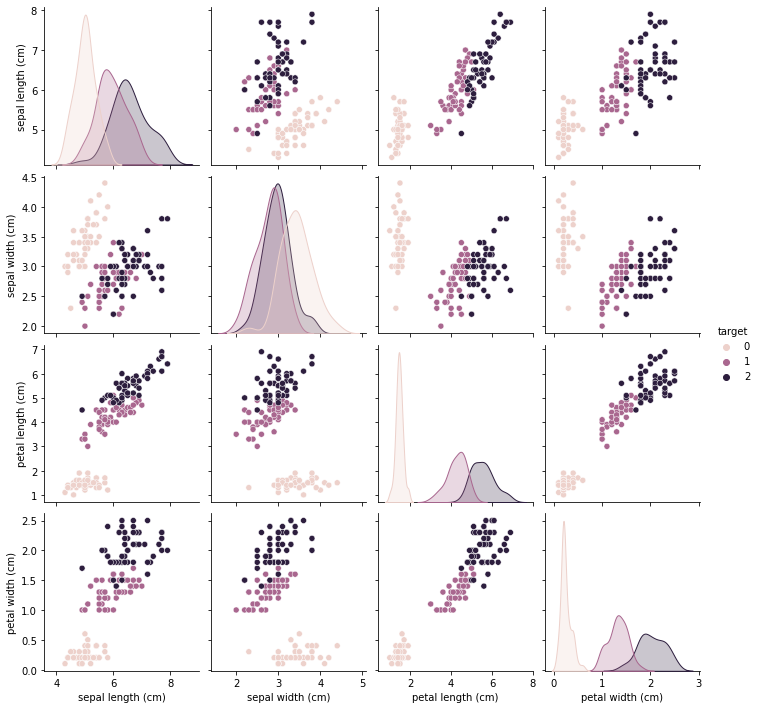

Você deve executar o experimento para cada par *features*, colorindo de acordo com o resultado fornecido pelo modelo de clusterização. Nos elementos da diagonal, você deve executar o cálculo de densidade dos elementos do conjunto usando `KDE` (`bandwidth=1.0, kernel='gaussian'`), também de acordo com a saída do modelo. Compare os experimentos entre si e com o que deveria ser a saída correta dos dados, segundo os rótulos originais do *dataset*.

Documente todas as etapas em um arquivo Jupyter Notebook (`.ipynb`) que inclua as análises, o código e as justificativas. Lembre-se de que é fundamental justificar todas as decisões tomadas ao longo do processo e documentar as análises de forma clara e concisa. Este trabalho tem como objetivo proporcionar uma compreensão prática da seleção e avaliação de algoritmos de agrupamento em cenários de aprendizado não-supervisionado.

Envie seu Jupyter Notebook até a data de entrega especificada nesta tarefa.

## Solução


### Carga do conjunto de dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings("ignore")


In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
kmeans_params = {'n_clusters': [2, 3, 6]}
gmm_params = {'n_components': [2, 3, 6], 'covariance_type': ['full', 'diag', 'spherical']}
dbscan_params = {'eps': [0.5, 1, 1.5], 'min_samples': [5, 10, 25]}

In [4]:
X = df.drop('target', axis=1).copy()
y_true = df['target'].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

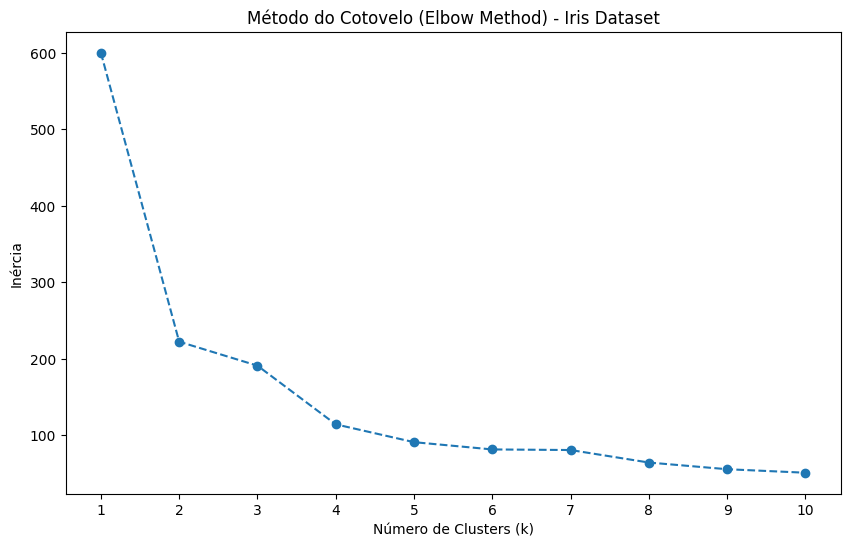

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method) - Iris Dataset')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.xticks(K_range)
plt.show()

In [7]:
def plot_clusters(ax, data, labels, title):
    unique_labels = np.unique(labels)
    
    cluster_labels = sorted([l for l in unique_labels if l != -1])
    num_clusters = len(cluster_labels)
    
    if num_clusters > 0:
        colors_list = plt.cm.Spectral(np.linspace(0, 1, num_clusters))
        color_map = {k: colors_list[i] for i, k in enumerate(cluster_labels)}
    else:
        color_map = {}
        
    color_map[-1] = (0, 0, 0, 1)

    for k in unique_labels:
        col = color_map[k]
        
        class_member_mask = (labels == k)
        xy = data[class_member_mask]
        
        if k == -1:
            ax.plot(xy[:, 0], xy[:, 1], 'x', markerfacecolor=tuple(col),
                    markeredgecolor=tuple(col), markersize=4, alpha=0.6)
        else:
            ax.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                    markeredgecolor='k', markersize=7, alpha=0.8)
    
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Petal Length (Scaled)', fontsize=8)
    ax.set_ylabel('Petal Width (Scaled)', fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=8)

### K-means

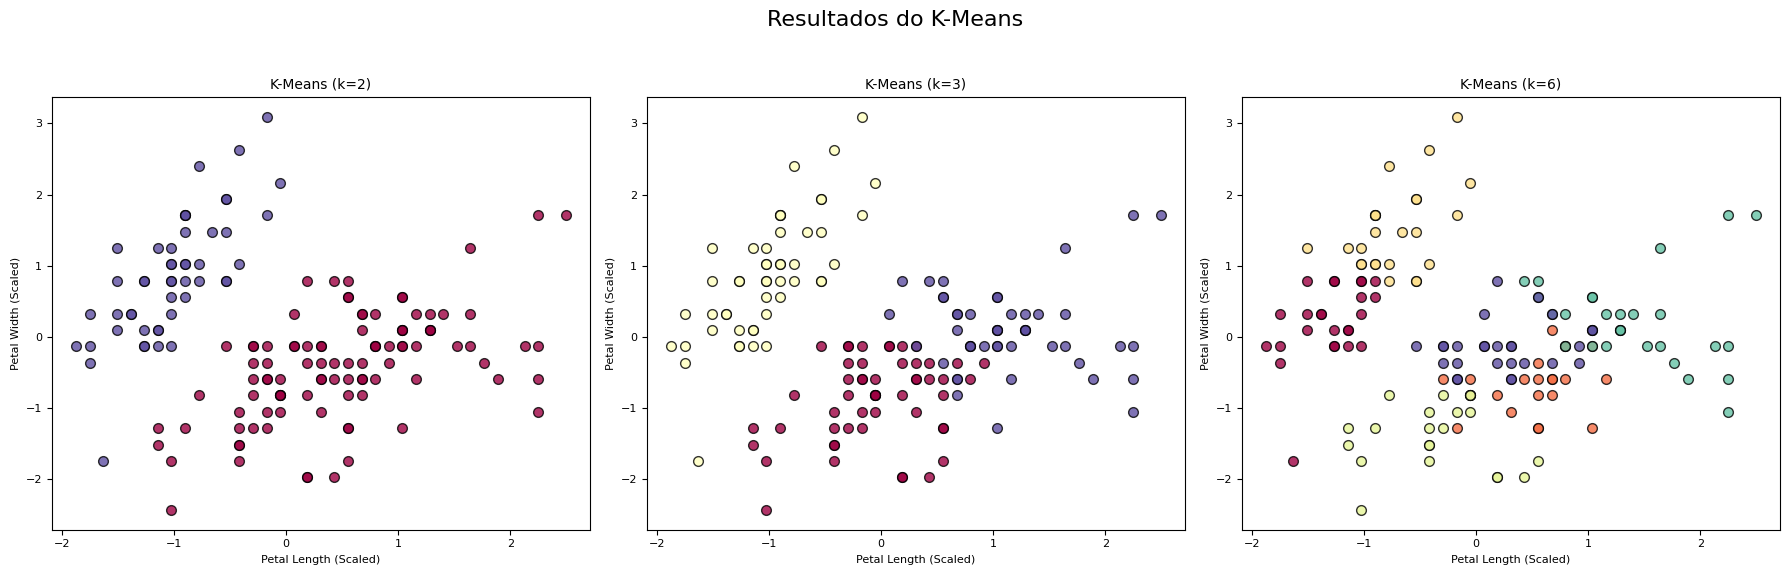

In [8]:
fig_kmeans, axes_kmeans = plt.subplots(1, 3, figsize=(18, 6), squeeze=False)
fig_kmeans.suptitle('Resultados do K-Means', fontsize=16)

for i, k in enumerate(kmeans_params['n_clusters']):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    plot_clusters(axes_kmeans[0, i], X_scaled, labels, f'K-Means (k={k})')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

### Gaussian

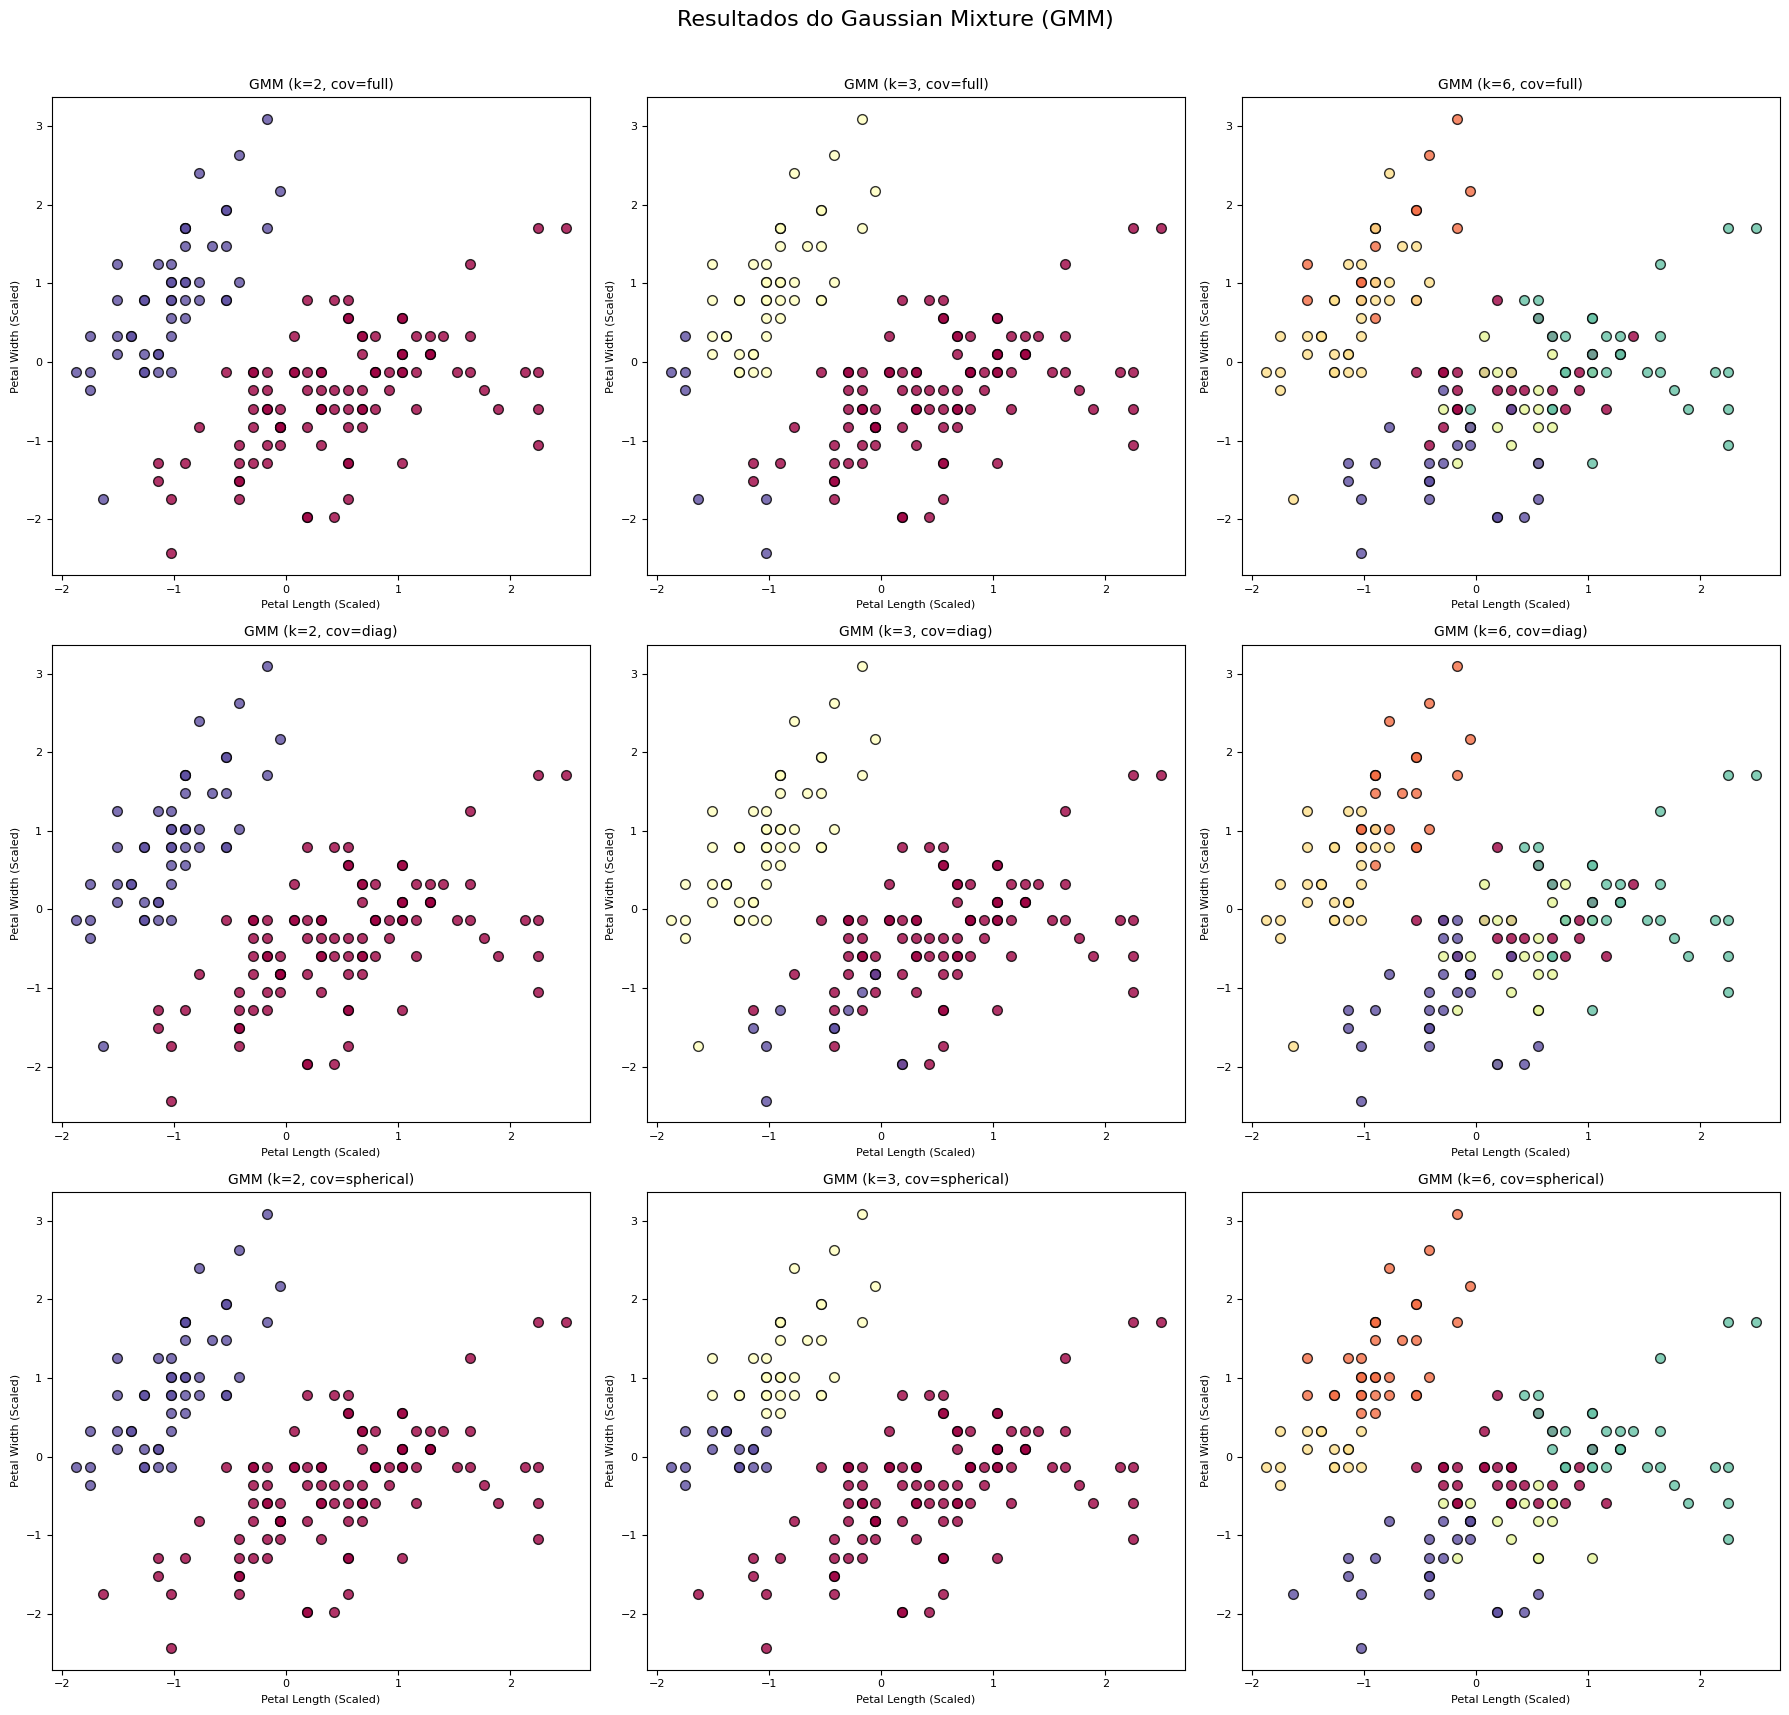

In [9]:
n_rows = len(gmm_params['covariance_type'])
n_cols = len(gmm_params['n_components'])
fig_gmm, axes_gmm = plt.subplots(n_rows, n_cols, figsize=(18, 18), squeeze=False)
fig_gmm.suptitle('Resultados do Gaussian Mixture (GMM)', fontsize=16)

for i, cov_type in enumerate(gmm_params['covariance_type']):
    for j, k in enumerate(gmm_params['n_components']):
        ax = axes_gmm[i, j]
        model = GaussianMixture(n_components=k, covariance_type=cov_type, random_state=42)
        labels = model.fit_predict(X_scaled)
        plot_clusters(ax, X_scaled, labels, f'GMM (k={k}, cov={cov_type})')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])

### DBSCAN

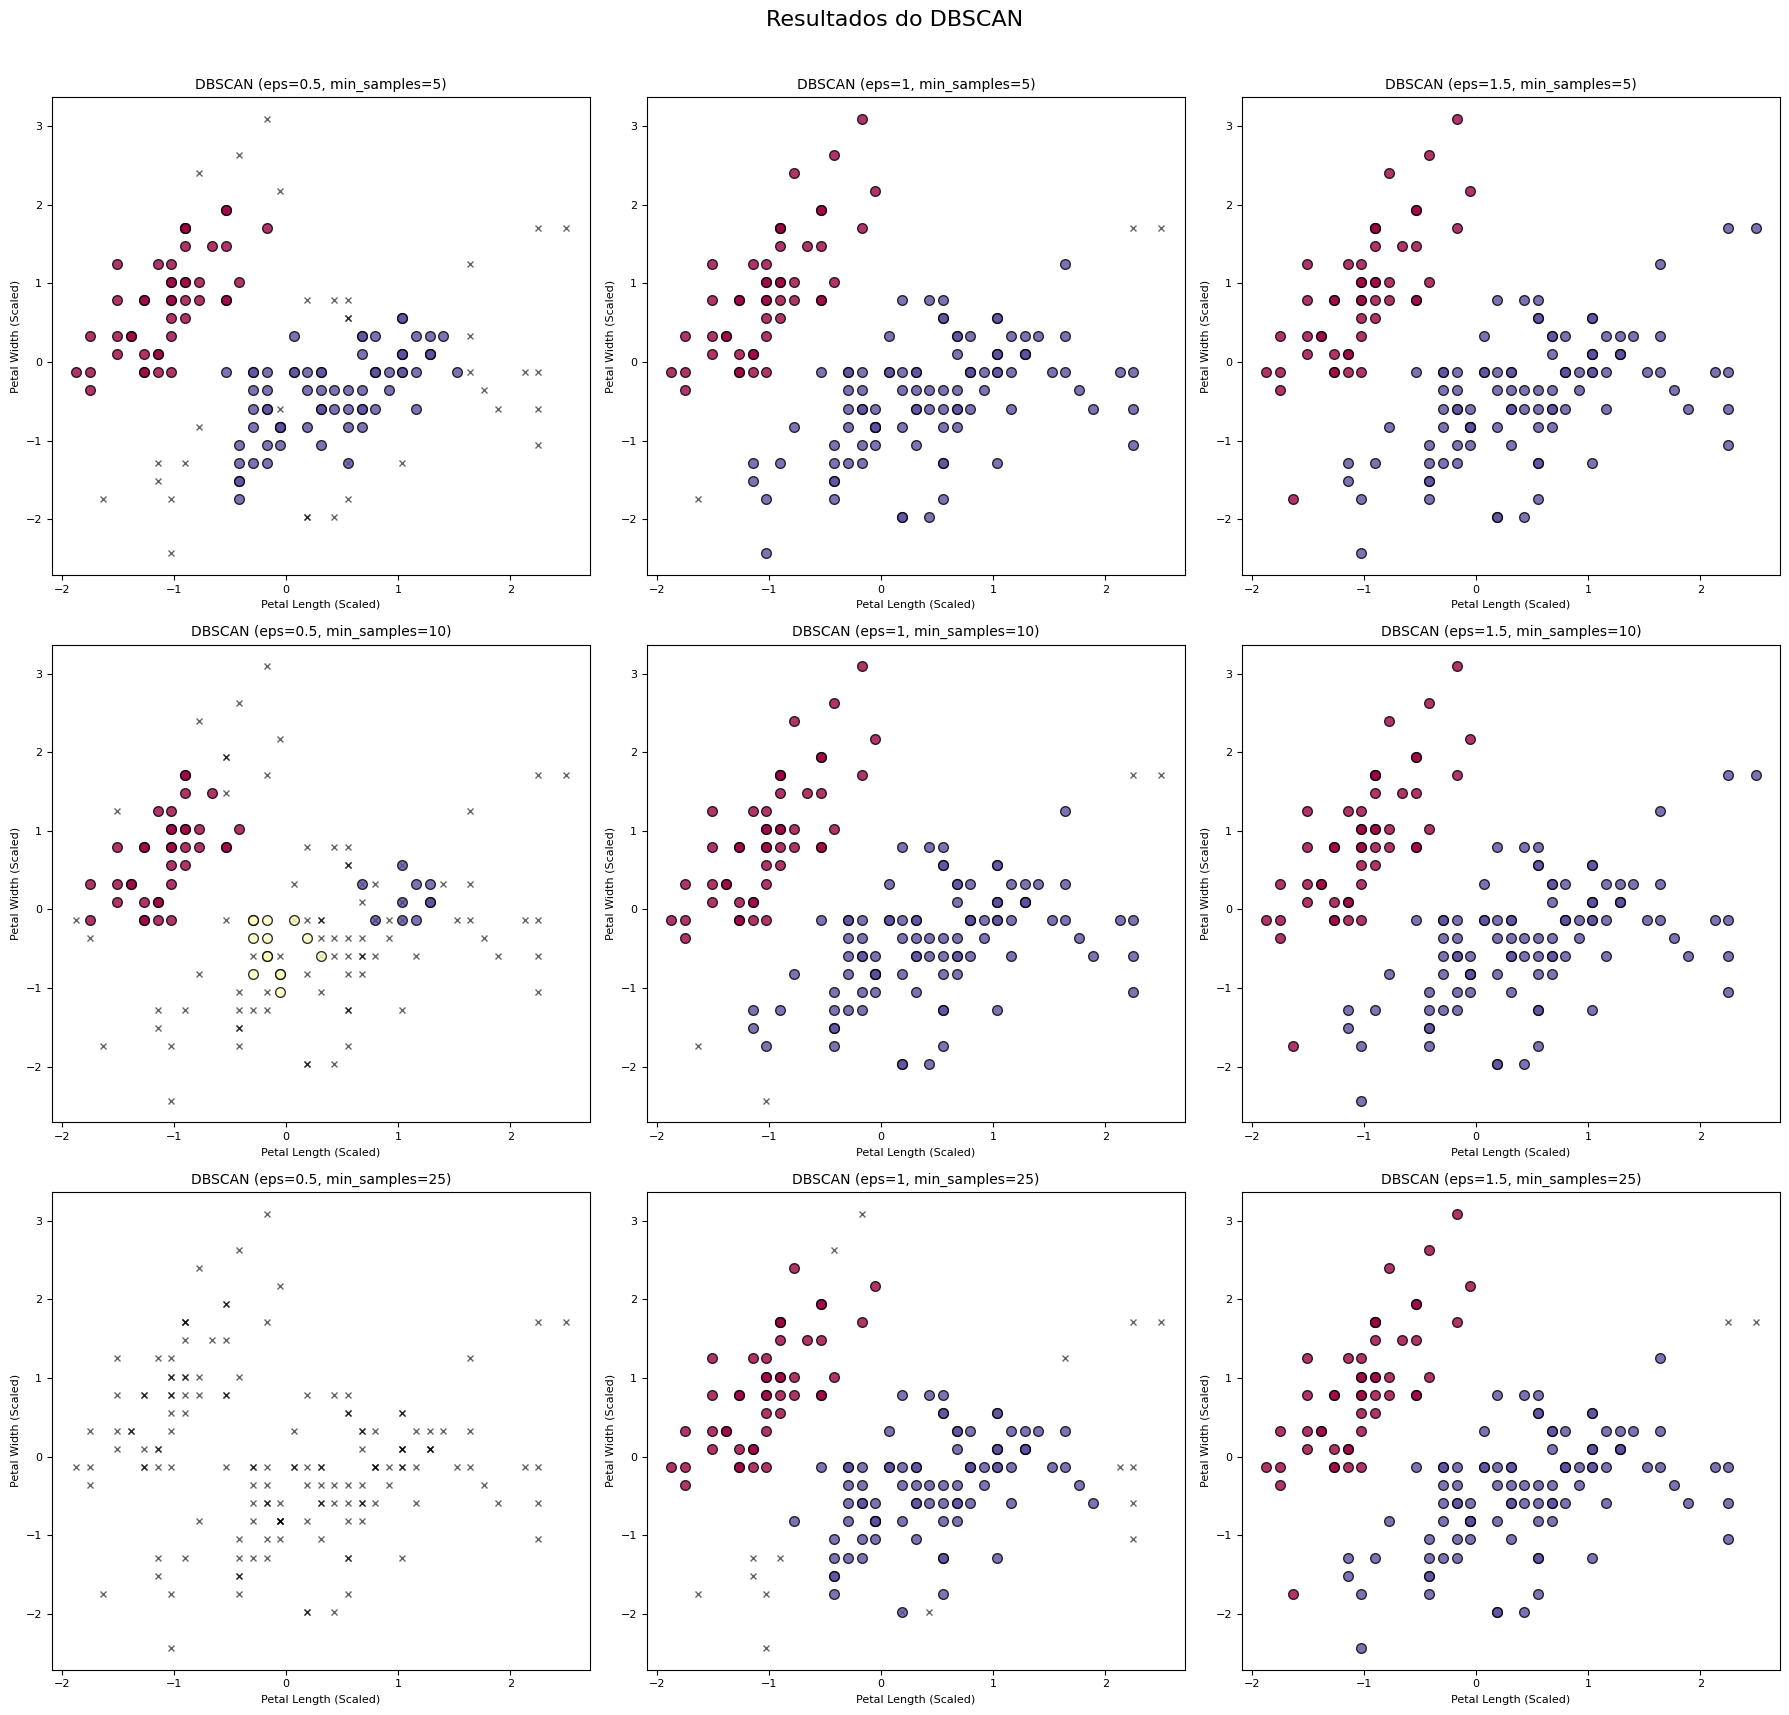

In [10]:
n_rows = len(dbscan_params['min_samples'])
n_cols = len(dbscan_params['eps'])
fig_dbscan, axes_dbscan = plt.subplots(n_rows, n_cols, figsize=(18, 18), squeeze=False)
fig_dbscan.suptitle('Resultados do DBSCAN', fontsize=16)

for i, min_samples in enumerate(dbscan_params['min_samples']):
    for j, eps in enumerate(dbscan_params['eps']):
        ax = axes_dbscan[i, j]
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)
        plot_clusters(ax, X_scaled, labels, f'DBSCAN (eps={eps}, min_samples={min_samples})')
        
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

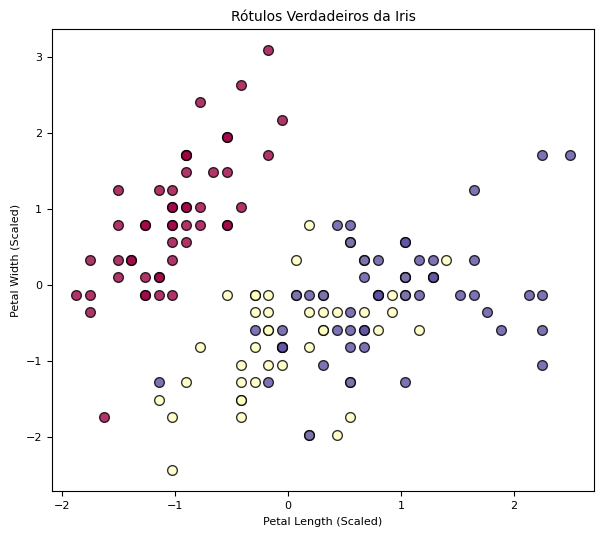

In [11]:
fig_true, ax_true = plt.subplots(1, 1, figsize=(7, 6))
plot_clusters(ax_true, X_scaled, y_true, 'Rótulos Verdadeiros da Iris')

plt.show()

### Análise dos resultados

#### 1. K-Means: Eficaz com o `k` correto
O K-Means demonstrou ser muito eficaz para este dataset, contanto que o número de clusters (`k`) seja correto.

* Com `k=3`, o K-Means produziu uma segmentação quase idêntica aos rótulos verdadeiros. Isso indica que os clusters do Iris são "globulares" (esféricos) e bem separados, que é o cenário ideal para o K-Means.
* Com `k=2`, o modelo falhou (sub-segmentação), e com `k=6`, ele também falhou (super-segmentação), dividindo clusters que deveriam ser um só.

---

#### 2. Gaussian Mixture (GMM): O modelo mais flexível e preciso
O GMM não apenas validou os resultados do K-Means, mas se mostrou superior em termos de flexibilidade.

* `k=3` com covariância `spherical` produziu um resultado idêntico ao K-Means, o que é esperado, pois essa configuração é uma versão probabilística do K-Means.
* `k=3` com covariância `full` ou `diag` foi o melhor modelo de todos. Ele capturou com sucesso a forma ligeiramente elíptica (alongada) dos clusters *Versicolor* e *Virginica*, algo que o K-Means (que assume círculos perfeitos) não consegue fazer.

---

#### 3. DBSCAN: A ferramenta errada para este problema
O DBSCAN foi o algoritmo menos adequado para este dataset.

* Ele é extremamente sensível aos hiperparâmetros `eps` e `min_samples`.
* Com `eps=0.5` (raio pequeno), o algoritmo só conseguiu identificar o cluster *Setosa* (que é muito denso e separado) e tratou os outros dois clusters como "ruído" (pontos pretos).
* Com `eps=1.0` ou `1.5` (raio grande), o algoritmo fundiu os clusters *Versicolor* e *Virginica* em um único grupo, pois eles estão muito próximos e o DBSCAN não conseguiu encontrar uma região de "baixa densidade" entre eles.

---

#### Síntese Final
A principal lição deste exercício é que **não existe um "melhor" algoritmo de agrupamento, e sim o algoritmo "certo" para a estrutura dos dados.**

1.  Para o Iris, que possui clusters globulares e bem definidos, o **K-Means com `k=3`** é uma solução simples e excelente.
2.  O **Gaussian Mixture (GMM)** é uma escolha ainda mais robusta, pois sua flexibilidade para modelar a forma (covariância) dos clusters permitiu um ajuste mais preciso.
3.  O **DBSCAN** é uma ferramenta poderosa para encontrar clusters de formas arbitrárias e identificar ruído, mas ele falhou aqui porque os clusters do Iris não têm formas estranhas e os dois grupos principais estão muito próximos para serem separados por densidade.